# Report

In [140]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast

In [141]:
root = Path.cwd().parent
metrics_data = pd.read_csv(f"{root}/results/metrics/results_20260224_222500.csv")
valid_data = pd.read_csv(f"{root}/results/predictions/results_20260225_083719.csv")
test_data = pd.read_csv(f"{root}/results/predictions/results_20260225_084341.csv")
data_test = pd.read_csv(f"{root}/data/test.csv")
data_train = pd.read_csv(f"{root}/data/train.csv")

In [142]:
primary_metric_train = data_train["target"].value_counts(normalize=True) * 100
print("Train dataset")
print(primary_metric_train)
primary_metric_percent_test = data_test["target"].value_counts(normalize=True) * 100
print()
print("Test dataset")
print(primary_metric_percent_test)

Train dataset
target
0    88.733333
1    11.266667
Name: proportion, dtype: float64

Test dataset
target
0    88.733333
1    11.266667
Name: proportion, dtype: float64


#### METRIC CHOICE: f1 instead of accuracy (88:12 imbalance)

Accuracy fails at 88:12 - predicting majority class always gives 88%
without detecting minority class (recall=0%).

F1-score (scoring='f1') balances precision and recall, penalizing:
- False alarms (FP) AND misses (FN)
- Perfect for moderate 1:7 imbalance

## Metrics analysis

### Roc acurracy metrics data

In [143]:
def plot_heatmap(df, value, index, columns, title, figsize=(12, 6)):
    pivot = df.pivot_table(
        values=value,
        index=index,
        columns=columns,
        aggfunc='mean'
    )

    plt.figure(figsize=figsize)
    sns.heatmap(pivot, annot=True, cmap='coolwarm', fmt='.3f')
    plt.title(title)
    plt.tight_layout()
    plt.show()


def plot_metric_heatmaps(df, scores):
    for score in scores:
        plot_heatmap(df, score, 'model', 'scaler', f"{score} vs Model and Scaler")
        plot_heatmap(df, score, 'model', 'balancing_name', f"{score} vs Model and Balancing")

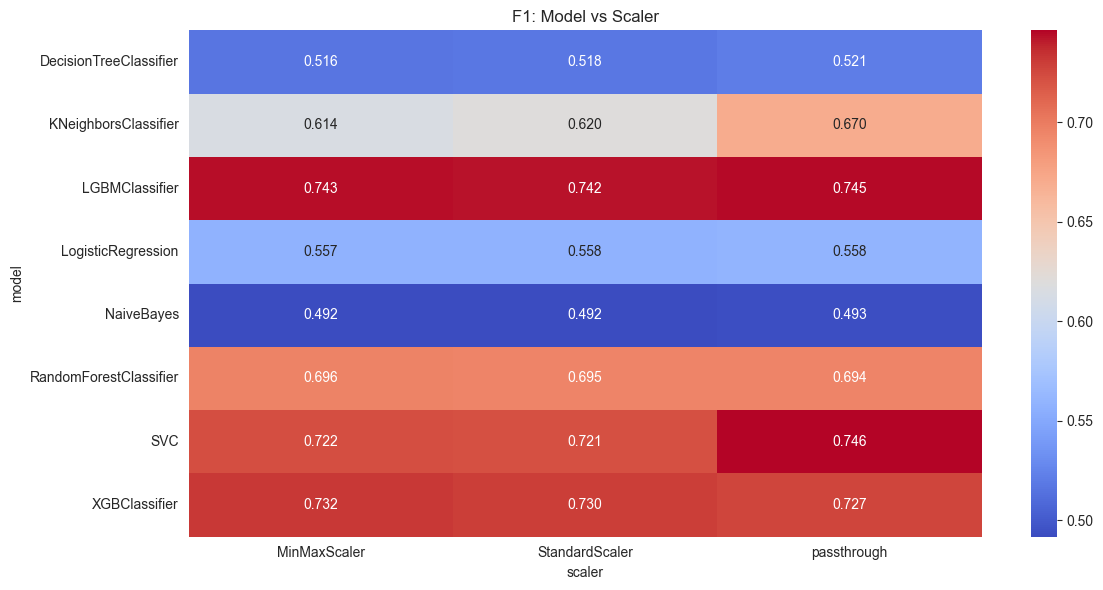

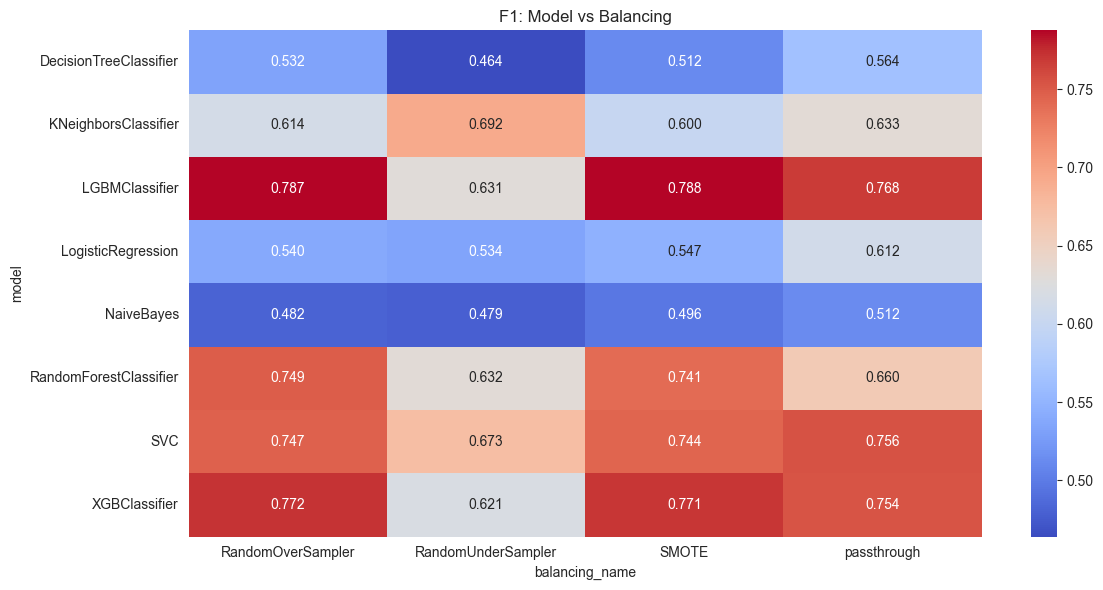

In [144]:
plot_heatmap(metrics_data, 'f1', 'model', 'scaler', "F1: Model vs Scaler")
plot_heatmap(metrics_data, 'f1', 'model', 'balancing_name', "F1: Model vs Balancing")

---

#### Figure description

The figure presents two heatmaps showing the **average F1-score obtained by different classification models** under various preprocessing configurations.
The upper heatmap compares model performance across different **feature scaling techniques**, while the lower heatmap evaluates the impact of different **data balancing strategies** on model performance.

The color intensity represents the magnitude of the F1-score, with warmer colors indicating better performance.

---

#### Key observations

**Model vs scaler**

* Tree-based models such as **LightGBM, XGBoost, RandomForest, and SVC** achieve the highest F1-scores.
* **LightGBM** consistently provides the best performance (~0.74–0.75) regardless of the scaler used.
* The effect of scaling appears minimal for most models, particularly for **tree-based algorithms**, where performance remains nearly unchanged across scalers.
* **KNN** shows noticeable improvement when scaling is applied, which is consistent with the distance-based nature of the algorithm.
* **Naive Bayes** and **Decision Tree** demonstrate the lowest F1-scores overall.

---

**Model vs balancing method**

* The balancing strategy has a **significant impact on model performance**, especially for ensemble models.
* **LightGBM and XGBoost achieve the highest F1-scores when oversampling techniques (RandomOverSampler or SMOTE) are applied**, reaching values close to **0.78**.
* **RandomUnderSampler consistently reduces model performance**, suggesting that removing majority-class samples leads to information loss.
* **SVC** benefits from balancing techniques, showing improved performance with SMOTE and oversampling.
* **Logistic Regression** shows moderate improvements with balancing but remains less competitive compared to ensemble models.

---

#### Interpretation

The results indicate that **model performance is more sensitive to class balancing strategies than to feature scaling methods**.
This behavior aligns with expectations, as tree-based models are generally invariant to feature scaling but can benefit significantly from improved class distribution.

Ensemble methods, particularly **LightGBM and XGBoost**, demonstrate strong robustness and consistently outperform other algorithms across different preprocessing configurations.

---


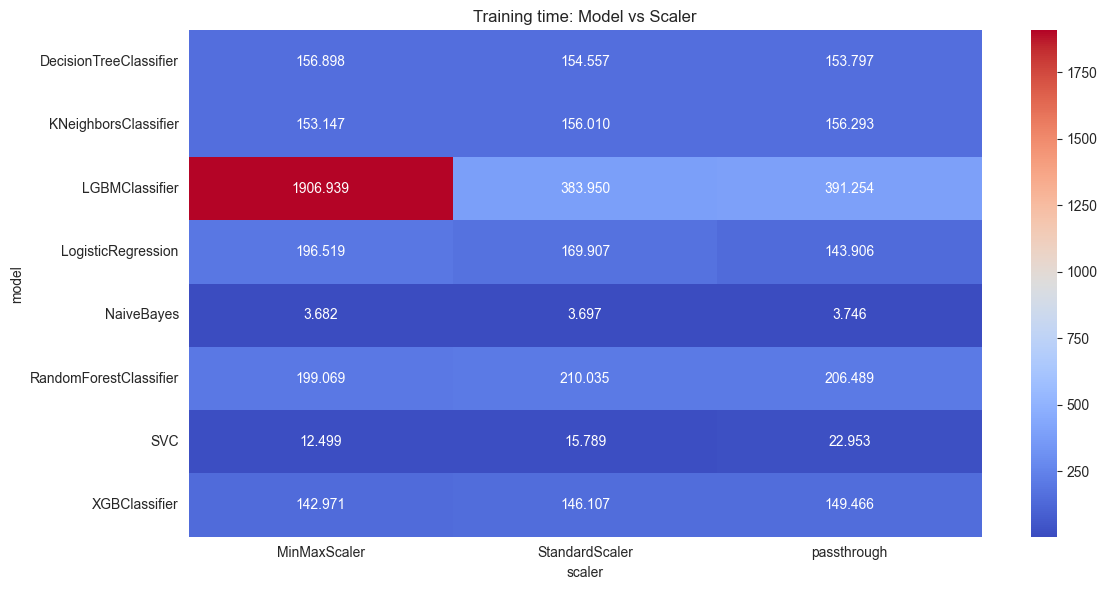

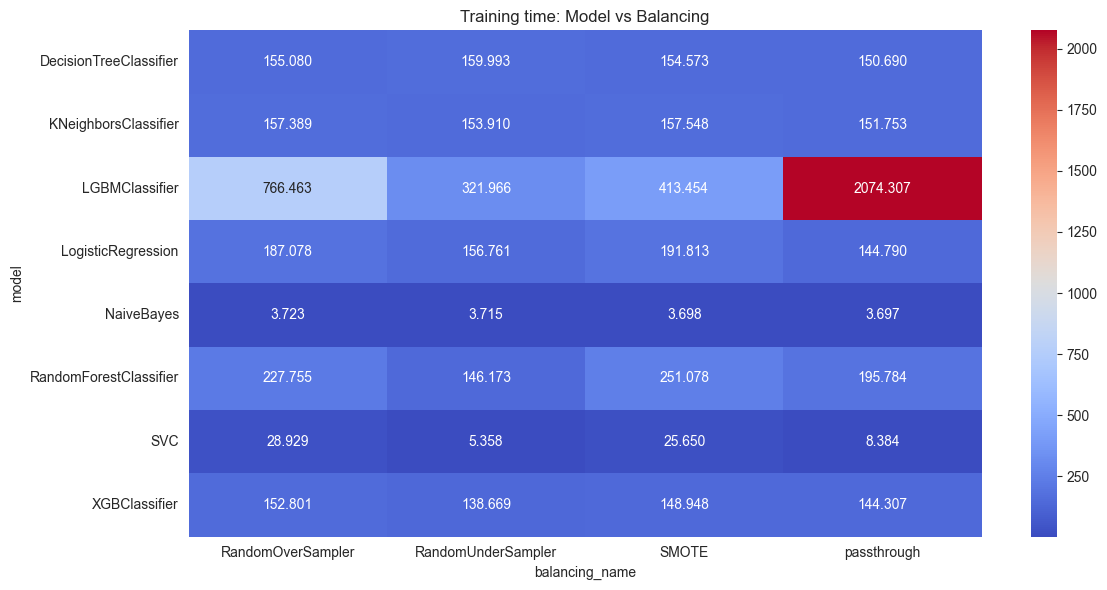

In [145]:
plot_heatmap(metrics_data, 'training_time', 'model', 'scaler', "Training time: Model vs Scaler")
plot_heatmap(metrics_data, 'training_time', 'model', 'balancing_name', "Training time: Model vs Balancing")

#### Figure description

The figure presents two heatmaps illustrating the **average training time of different classification models** under various preprocessing configurations.
The upper heatmap compares training time across different **feature scaling techniques**, while the lower heatmap shows how **different class balancing strategies** influence computational cost during model training.

Color intensity represents training duration, where warmer colors indicate longer training times.

---

#### Key observations

**Model vs scaler**

* **LightGBM** exhibits significantly higher training time when combined with **MinMaxScaler**, reaching values above **1900**, which is substantially higher than other configurations.
* When **StandardScaler or no scaling (passthrough)** is applied, the training time for LightGBM decreases dramatically, indicating that scaling choice may affect pipeline overhead.
* **RandomForest** and **LogisticRegression** show relatively stable training times across different scalers.
* **Naive Bayes** is by far the fastest model, with training time close to **3–4 units**, indicating extremely low computational complexity.
* **SVC** remains computationally inexpensive in this setup, although its training time increases slightly when scaling is removed.

---

**Model vs balancing method**

* The choice of balancing technique introduces **considerable variability in training time**, particularly for ensemble models.
* **LightGBM** shows the largest increase in computational cost when no balancing method is applied, reaching over **2000**, which is the highest value observed in the analysis.
* **RandomForest** training time also varies noticeably depending on the balancing technique, suggesting sensitivity to the number of training samples generated by oversampling methods.
* **RandomUnderSampler** tends to **reduce training time**, as expected, since it decreases the size of the training dataset.
* **SVC** shows a substantial reduction in training time when **RandomUnderSampler** is used, reflecting the algorithm's sensitivity to dataset size.
* **Naive Bayes** again remains computationally minimal and largely unaffected by balancing strategies.

---

#### Interpretation

The results demonstrate that **training time is strongly influenced by dataset size and preprocessing strategies**, particularly for ensemble-based models.
Oversampling techniques increase the number of training samples, which can significantly increase computational cost, while undersampling methods reduce training complexity by shrinking the dataset.

Tree-based boosting models such as **LightGBM** show the greatest variability in training time, indicating higher sensitivity to preprocessing pipeline configurations.

---

#### Implication

These results highlight an important trade-off between **model performance and computational efficiency**.
While ensemble models such as LightGBM and RandomForest may achieve strong predictive performance, their training cost can increase substantially depending on the chosen balancing strategy.
In contrast, simpler models like **Naive Bayes or Logistic Regression** remain computationally efficient and stable across preprocessing configurations.


## Test data

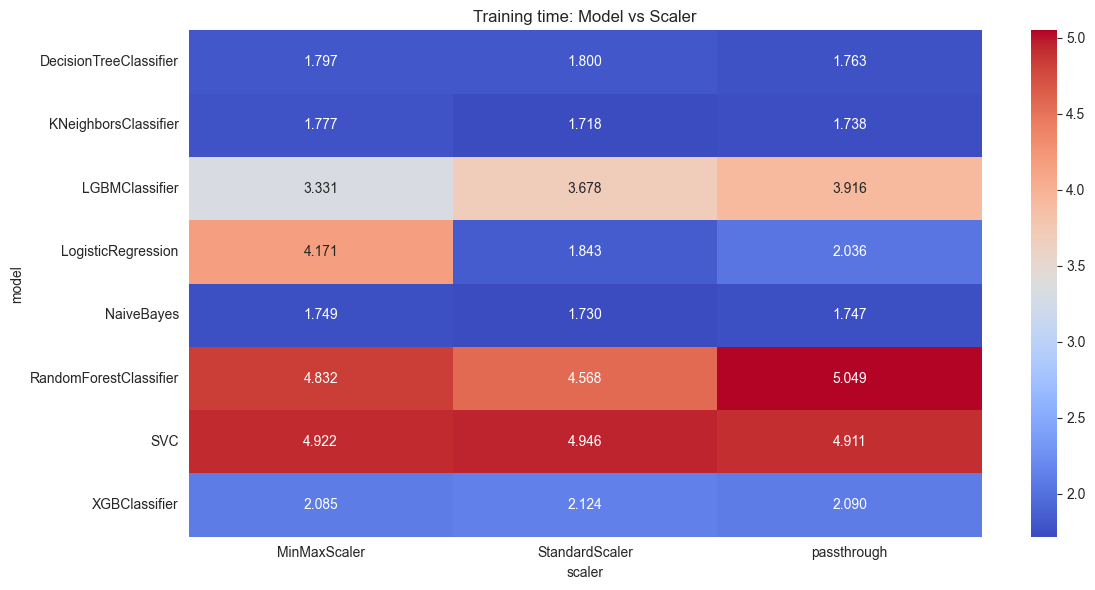

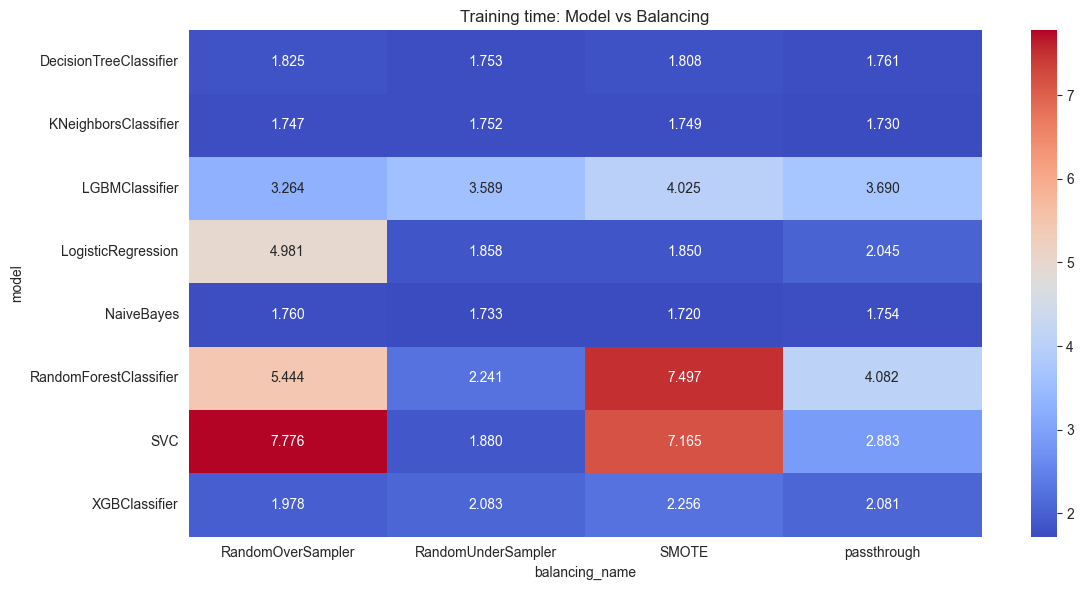

In [146]:
plot_heatmap(test_data, 'training_time', 'model', 'scaler', "Training time: Model vs Scaler")
plot_heatmap(test_data, 'training_time', 'model', 'balancing_name', "Training time: Model vs Balancing")


#### Figure description

The figure presents two heatmaps illustrating the **average training time of multiple classification models** under different preprocessing configurations.

The upper heatmap shows the relationship between **model type and class balancing strategy**, including:

* RandomOverSampler
* RandomUnderSampler
* SMOTE
* passthrough (no balancing)

The lower heatmap presents the relationship between **model type and feature scaling method**, including:

* MinMaxScaler
* StandardScaler
* passthrough (no scaling)

The color intensity represents the magnitude of training time, where warmer colors indicate longer computational time.

---

#### Key observations

**Model vs balancing method**

* Training time varies significantly depending on the applied **balancing strategy**, especially for more complex models.
* **SVC and RandomForest** exhibit the highest training times when oversampling techniques such as **RandomOverSampler and SMOTE** are applied.
* **RandomUnderSampler consistently reduces training time**, as it decreases the size of the training dataset.
* **SMOTE introduces the largest computational overhead** for several models due to the generation of synthetic samples.
* **Naive Bayes, KNN, and Decision Tree** remain relatively stable and computationally efficient across all balancing configurations.
* **XGBoost and LightGBM** show moderate training times with slight increases when oversampling methods are used.

---

**Model vs scaler**

* The choice of **feature scaling technique has a relatively small impact on training time** for most models.
* **RandomForest and SVC** remain the most computationally intensive models across all scaling strategies.
* **Naive Bayes, KNN, and Decision Tree** consistently demonstrate the lowest training times.
* **Logistic Regression shows noticeably longer training time when MinMaxScaler is used**, compared to StandardScaler or no scaling.
* **LightGBM and XGBoost** maintain moderate and stable training times regardless of the applied scaling method.

---

#### Interpretation

The results indicate that **class balancing strategies have a stronger impact on training time than feature scaling methods**.

Oversampling techniques increase the number of training samples, which leads to higher computational costs, particularly for models with higher algorithmic complexity such as **SVC and RandomForest**.

In contrast, undersampling techniques reduce the dataset size and therefore decrease training time.


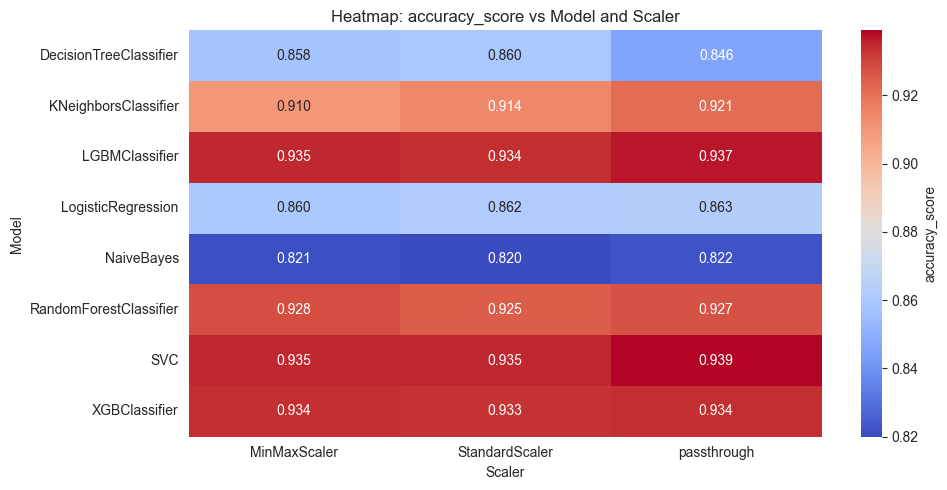

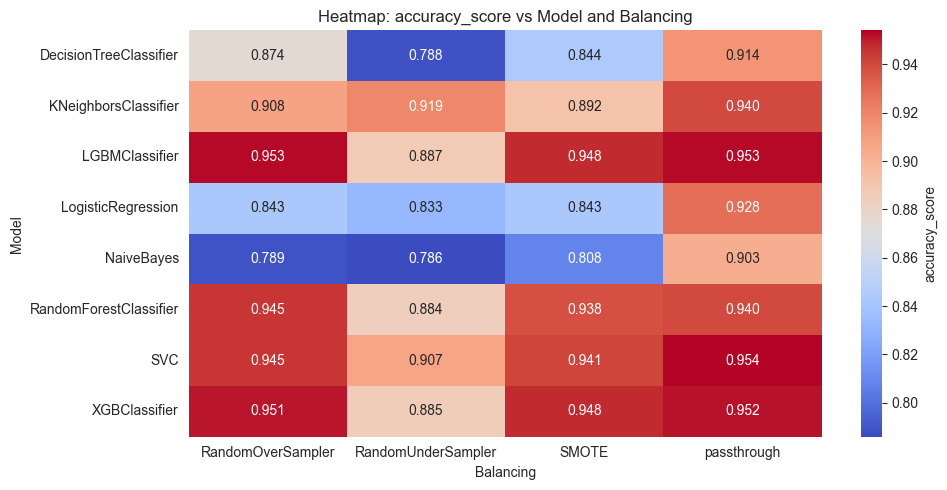

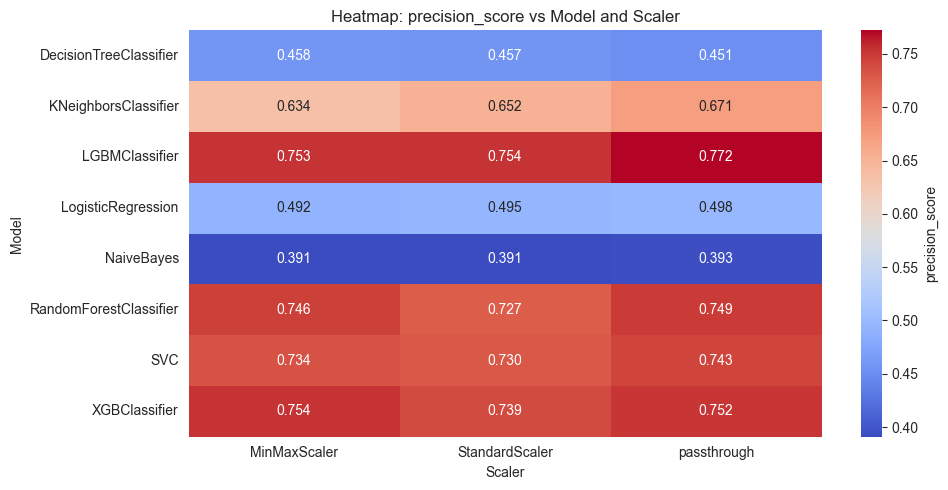

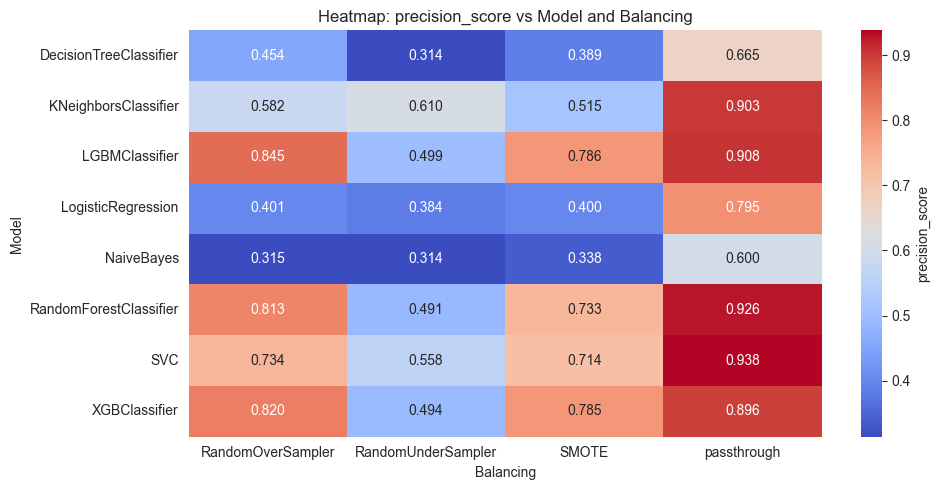

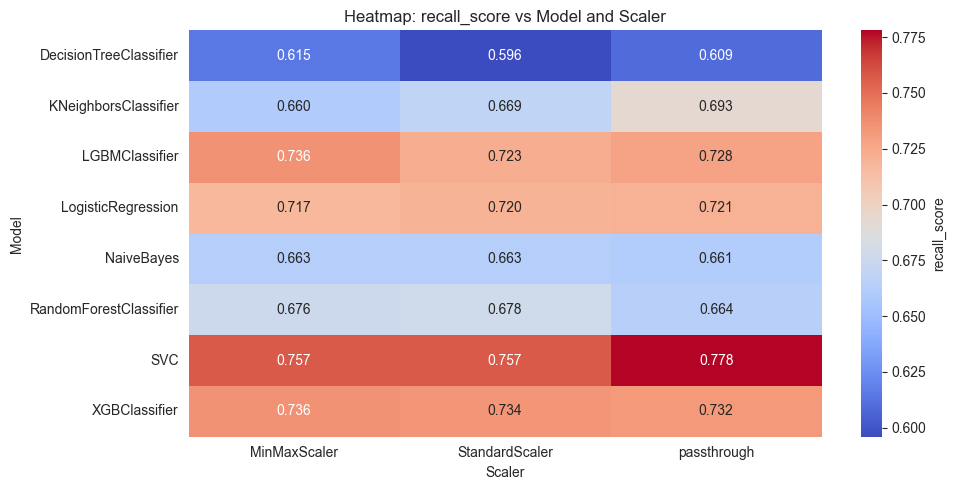

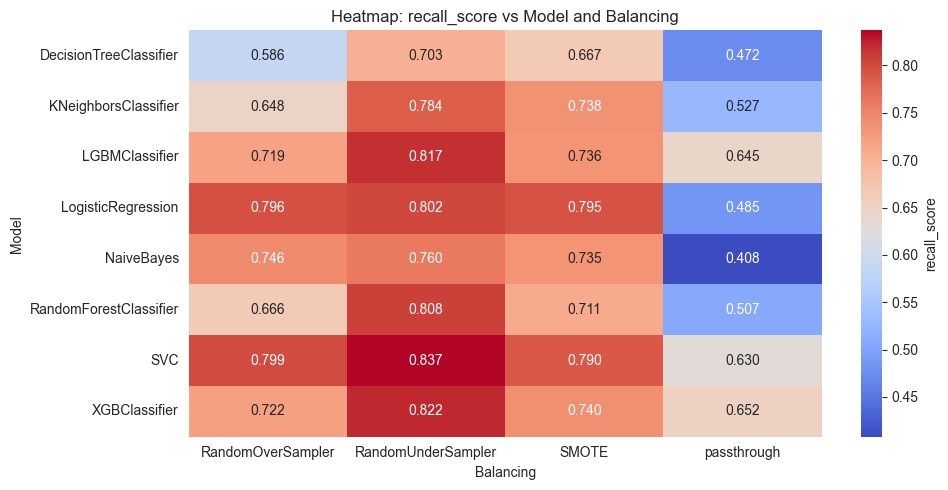

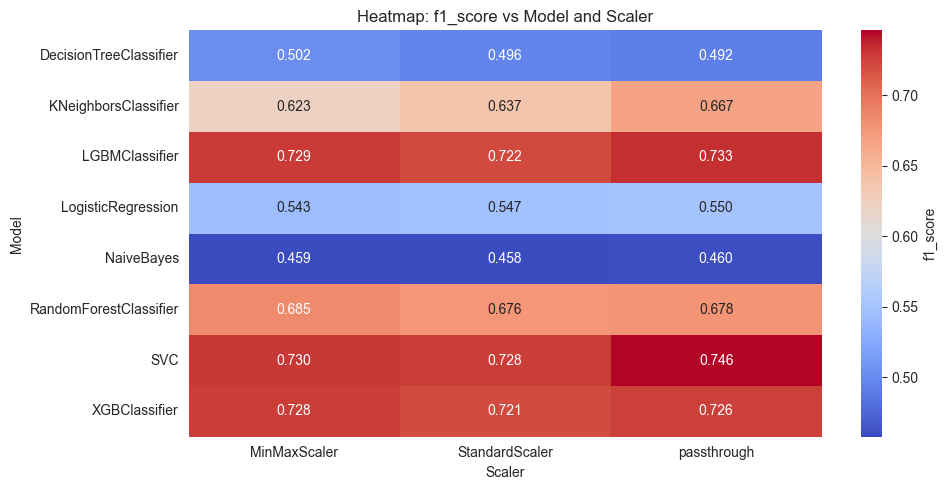

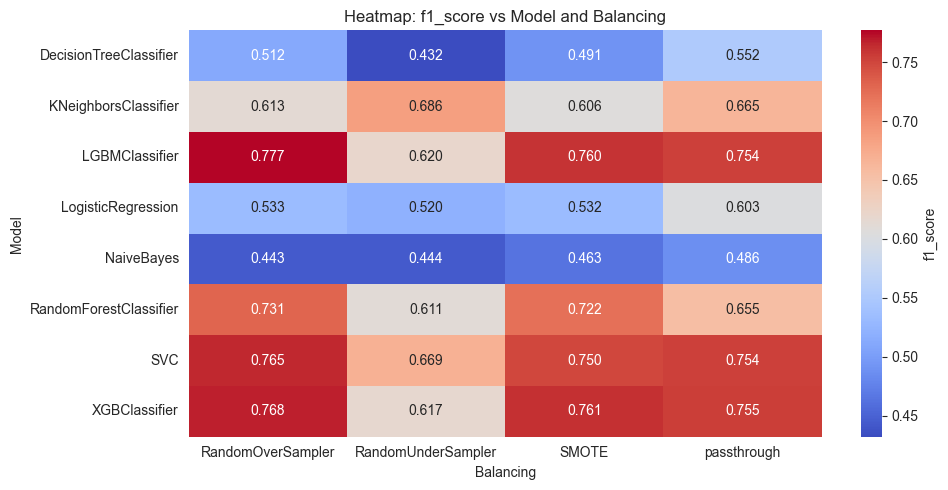

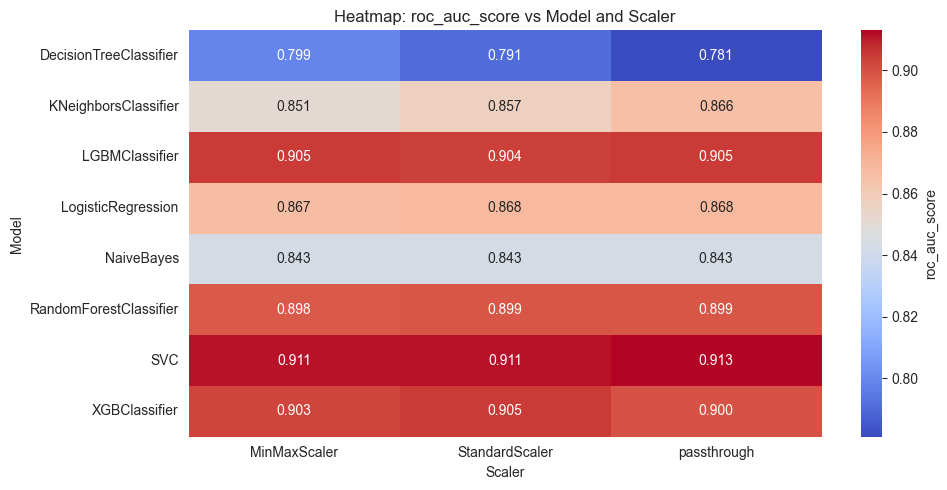

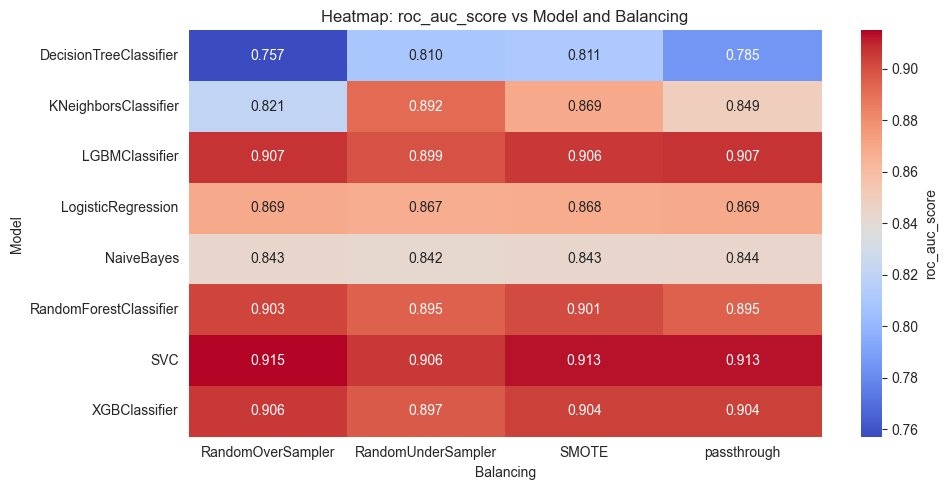

In [147]:
scores = ['accuracy_score', 'precision_score', 'recall_score', 'f1_score', 'roc_auc_score']

for score in scores:
    pivot_scaler = test_data.groupby(['model', 'scaler'])[score].mean().reset_index().pivot(
        index='model', columns='scaler', values=score
    ).round(3)

    plt.figure(figsize=(10, 5))
    sns.heatmap(pivot_scaler, annot=True, cmap='coolwarm', fmt='.3f',
                cbar_kws={'label': score})
    plt.title(f"Heatmap: {score} vs Model and Scaler")
    plt.ylabel("Model")
    plt.xlabel("Scaler")
    plt.tight_layout()
    plt.show()

    pivot_balancing = test_data.groupby(['model', 'balancing_name'])[score].mean().reset_index().pivot(
        index='model', columns='balancing_name', values=score
    ).round(3)

    plt.figure(figsize=(10, 5))
    sns.heatmap(pivot_balancing, annot=True, cmap='coolwarm', fmt='.3f',
                cbar_kws={'label': score})
    plt.title(f"Heatmap: {score} vs Model and Balancing")
    plt.ylabel("Model")
    plt.xlabel("Balancing")
    plt.tight_layout()
    plt.show()


#### Accuracy score analysis

##### Figure description

The figure presents two heatmaps illustrating the **average accuracy score obtained by different classification models** under various preprocessing configurations.

The upper heatmap compares model performance across different **feature scaling techniques** (MinMaxScaler, StandardScaler, and passthrough), while the lower heatmap evaluates the influence of different **class balancing strategies** (RandomOverSampler, RandomUnderSampler, SMOTE, and passthrough).

The color intensity represents the magnitude of the accuracy score, where warmer colors indicate better classification performance.

---

##### Key observations

###### Model vs scaler

* **Feature scaling has only a minor effect on accuracy** for most models.
* **Tree-based ensemble models (LightGBM, RandomForest, XGBoost)** consistently achieve the highest accuracy values (~0.93–0.94).
* **SVC also performs strongly**, reaching the highest accuracy (~0.939) when no scaling is applied.
* **KNN slightly benefits from scaling**, which aligns with its distance-based algorithmic nature.
* **Naive Bayes produces the lowest accuracy (~0.82)** across all scaling configurations.
* Overall, most models demonstrate **robust performance regardless of scaling method**.

---

###### Model vs balancing method

* **Balancing strategy has a stronger effect on accuracy than scaling**.
* In many cases, **no balancing (passthrough)** produces the highest accuracy values.
* **RandomUnderSampler significantly reduces accuracy**, especially for Decision Tree and Naive Bayes.
* **RandomOverSampler and SMOTE maintain strong performance**, particularly for ensemble models.
* **SVC achieves the highest overall accuracy (~0.954)** when no balancing is applied.

---

##### Interpretation

The results suggest that **accuracy is relatively insensitive to feature scaling but more affected by class balancing strategies**.

High accuracy without balancing indicates that the dataset is likely **dominated by the majority class**, allowing models to achieve strong performance even without addressing class imbalance. However, accuracy alone may not reflect performance on minority-class predictions.

---

#### Precision score analysis

###### Figure description

The figure presents heatmaps showing the **average precision score achieved by classification models** under different preprocessing configurations.

The upper heatmap evaluates the effect of **feature scaling**, while the lower heatmap examines the influence of **class balancing techniques** on precision.

Higher precision values indicate better ability of a model to correctly identify positive predictions while minimizing false positives.

---

##### Key observations

###### Model vs scaler

* **Feature scaling has limited impact on precision** for most models.
* **LightGBM, XGBoost, RandomForest, and SVC** achieve the highest precision values (~0.73–0.77).
* **KNN slightly improves with scaling**, reflecting its reliance on distance calculations.
* **Naive Bayes consistently shows the lowest precision (~0.39)**.
* Ensemble models consistently outperform simpler classifiers in terms of precision.

---

###### Model vs balancing method

* **Balancing strategies strongly affect precision**.
* **RandomUnderSampler significantly reduces precision**, often dropping below 0.50.
* **RandomOverSampler and SMOTE provide more balanced performance**, particularly for ensemble models.
* The highest precision values occur when **no balancing is applied**, with **SVC (~0.938)** and **RandomForest (~0.926)** achieving the best results.
* **KNN shows a strong increase in precision without balancing**, reaching values above **0.90**.

---

##### Interpretation

Precision tends to **decrease when aggressive balancing techniques are used**, particularly undersampling.

Reducing the majority class may increase the number of predicted positives, which can raise the number of **false positives**, thereby lowering precision. When no balancing is applied, models tend to be more conservative in predicting the positive class, resulting in higher precision.

---

#### Recall score analysis

##### Figure description

The figure presents two heatmaps illustrating the **average recall score obtained by classification models** under different preprocessing configurations.

The upper heatmap compares recall across different **feature scaling methods**, while the lower heatmap evaluates the impact of different **class balancing techniques**.

Higher recall values indicate a model’s ability to correctly identify a larger proportion of true positive observations.

---

##### Key observations

###### Model vs scaler

* **Scaling has minimal influence on recall** across most models.
* **SVC achieves the highest recall (~0.77)** when no scaling is applied.
* **LightGBM and XGBoost** also achieve strong recall values (~0.73–0.74).
* **Logistic Regression maintains relatively stable recall (~0.72)** regardless of scaling.
* **Decision Tree exhibits the lowest recall (~0.60)** across scaling configurations.

---

###### Model vs balancing method

* **Balancing strategies significantly increase recall** for most models.
* **RandomUnderSampler produces the highest recall values** across several models.
* **SVC and XGBoost achieve the strongest recall (~0.82–0.84)** under undersampling conditions.
* **Without balancing, recall values drop substantially**, indicating strong bias toward the majority class.
* Oversampling methods (RandomOverSampler and SMOTE) also improve recall but to a slightly lesser degree than undersampling.

---

##### Interpretation

The results indicate that **class balancing is crucial for improving recall**, as it increases the representation of minority-class samples during training.

Without balancing, models struggle to correctly identify minority-class observations, resulting in lower recall.

---

#### F1-score analysis

##### Figure description

The figure presents heatmaps showing the **average F1-score achieved by classification models** under different preprocessing configurations.

The upper heatmap compares performance across **feature scaling methods**, while the lower heatmap evaluates the effect of **class balancing strategies**.

F1-score represents the harmonic mean of precision and recall, providing a balanced measure of model performance.

---

##### Key observations

###### Model vs scaler

* **Scaling has a relatively small effect on F1-score**.
* **SVC, LightGBM, and XGBoost** consistently achieve the highest F1 values (~0.73–0.75).
* **RandomForest also performs strongly (~0.68)** across scaling configurations.
* **Naive Bayes and Decision Tree produce the lowest F1-scores**.
* Distance-based models like **KNN slightly benefit from scaling**.

---

###### Model vs balancing method

* **RandomOverSampler and SMOTE generally provide the best F1-score results**, particularly for ensemble models.
* **LightGBM achieves the highest F1-score (~0.77)** when oversampling is applied.
* **RandomUnderSampler reduces F1-score performance** for most models due to the loss of majority-class information.
* **SVC and XGBoost maintain strong F1-scores across multiple balancing strategies**.

---

##### Interpretation

F1-score reflects the **trade-off between precision and recall**, and the results indicate that **moderate oversampling techniques provide the most balanced performance**.

Undersampling may improve recall but often harms precision, resulting in lower F1-score.

---

#### ROC-AUC score analysis

##### Figure description

The figure presents heatmaps illustrating the **average ROC-AUC score achieved by classification models** under different preprocessing configurations.

The upper heatmap compares model performance across different **feature scaling methods**, while the lower heatmap evaluates the impact of **class balancing strategies** on ROC-AUC.

ROC-AUC measures the model’s ability to discriminate between positive and negative classes across different classification thresholds.

---

##### Key observations

###### Model vs scaler

* **Scaling has minimal impact on ROC-AUC scores**.
* **SVC achieves the highest ROC-AUC (~0.91)** across all scaling configurations.
* **LightGBM, XGBoost, and RandomForest** also achieve strong results (~0.90).
* **Naive Bayes produces stable but lower ROC-AUC (~0.84)** across all configurations.
* Overall, models maintain consistent ranking regardless of scaling strategy.

---

###### Model vs balancing method

* **Balancing strategies have only a moderate impact on ROC-AUC scores**.
* **SVC achieves the best ROC-AUC (~0.915)** when RandomOverSampler is applied.
* **LightGBM and XGBoost consistently maintain ROC-AUC around ~0.90**.
* **RandomUnderSampler slightly reduces ROC-AUC for several models**, indicating potential information loss.
* Ensemble models remain highly stable across balancing strategies.

---

##### Interpretation

ROC-AUC appears to be **less sensitive to preprocessing choices compared to other metrics**.

This suggests that most models maintain strong **ranking ability between classes**, even when class balancing strategies or scaling techniques change.

---

Jeśli chcesz, mogę też napisać jeszcze jedną sekcję, która w **raporcie robi największe wrażenie na rekruterach**:

**“Overall benchmark conclusions (Top insights)”** – czyli 5–6 najważniejszych wniosków z całego projektu.


## Valid data results

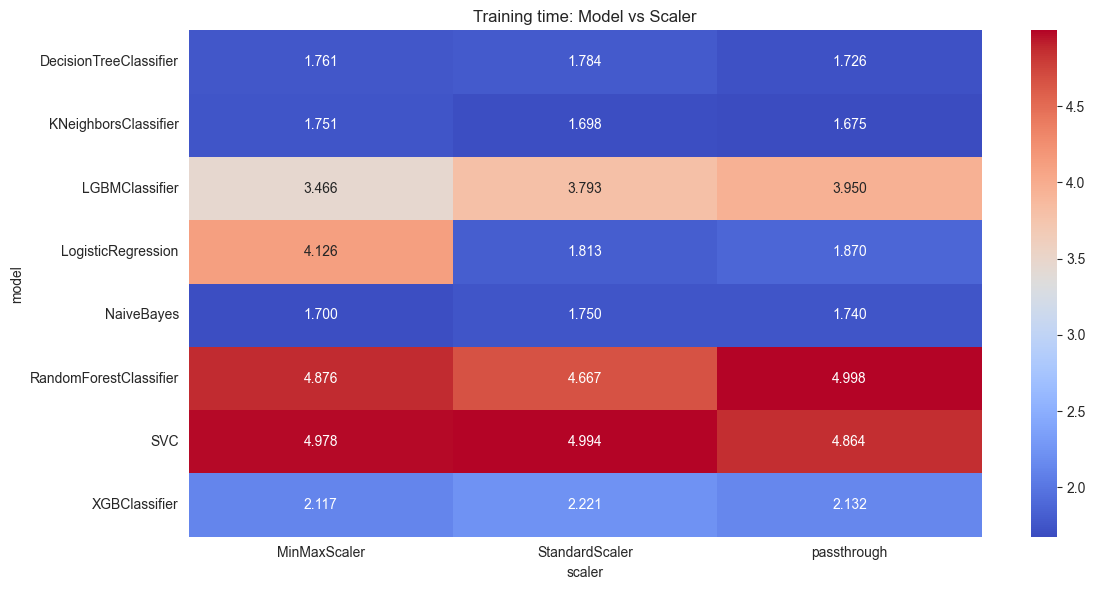

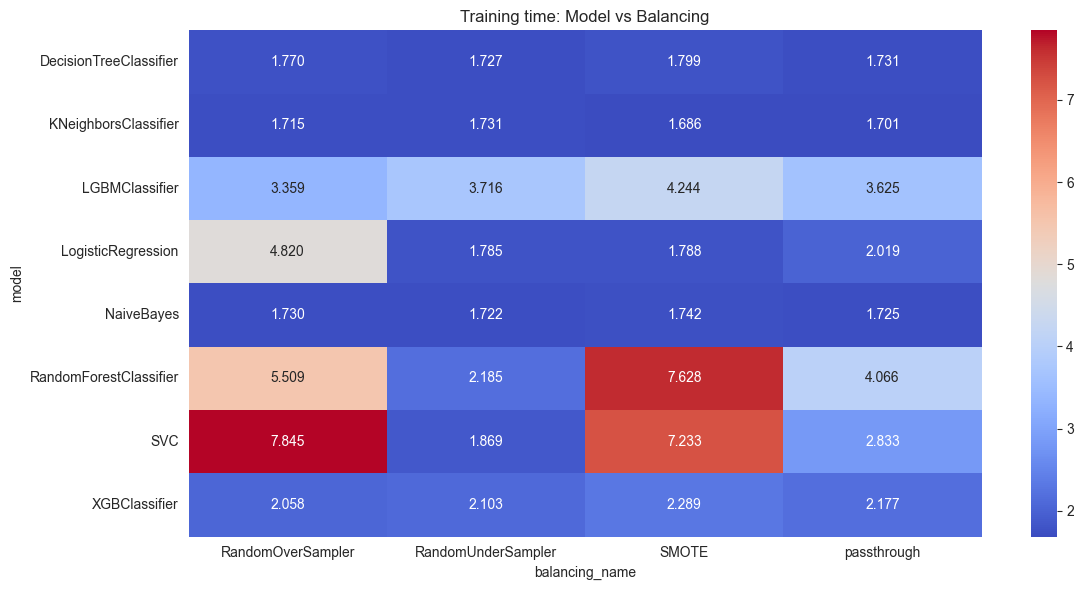

In [148]:
plot_heatmap(valid_data, 'training_time', 'model', 'scaler', "Training time: Model vs Scaler")
plot_heatmap(valid_data, 'training_time', 'model', 'balancing_name', "Training time: Model vs Balancing")


#### Figure description

The figure presents two heatmaps illustrating the **average training time of classification models** under different preprocessing configurations.
The upper heatmap shows the relationship between **model type and feature scaling method**, while the lower heatmap presents training time across different **class balancing strategies**.

The color gradient represents training duration, where warmer colors indicate longer training time.

---

#### Key observations

**Model vs scaler**

* The **choice of scaler has only a minor impact on training time** for most models.
* **RandomForest and SVC** are the most computationally expensive models, with training times consistently close to **5 units**.
* **Naive Bayes, KNN, and Decision Tree** remain among the fastest algorithms, with training times around **1.7–1.8** regardless of scaling.
* **Logistic Regression** shows a noticeable increase in training time when **MinMaxScaler** is used compared to StandardScaler or no scaling.
* **LightGBM and XGBoost** maintain moderate training times, indicating relatively efficient training compared to other ensemble methods.

---

**Model vs balancing method**

* The **balancing strategy has a stronger influence on training time than scaling**.
* **SMOTE and RandomOverSampler significantly increase training time** for several models, particularly **RandomForest and SVC**, due to the larger number of generated training samples.
* **RandomUnderSampler consistently reduces training time**, as it decreases the size of the training dataset.
* **SVC shows the highest sensitivity to oversampling**, reaching the largest training times when RandomOverSampler or SMOTE are applied.
* **Naive Bayes and KNN remain stable and computationally inexpensive**, indicating low sensitivity to dataset size.

---

#### Interpretation

The results confirm that **dataset size is a key driver of training time** across machine learning models.
Oversampling techniques increase the number of training observations, which leads to higher computational costs, especially for models with higher training complexity such as **SVC and RandomForest**.

Conversely, undersampling methods reduce dataset size and therefore improve computational efficiency.

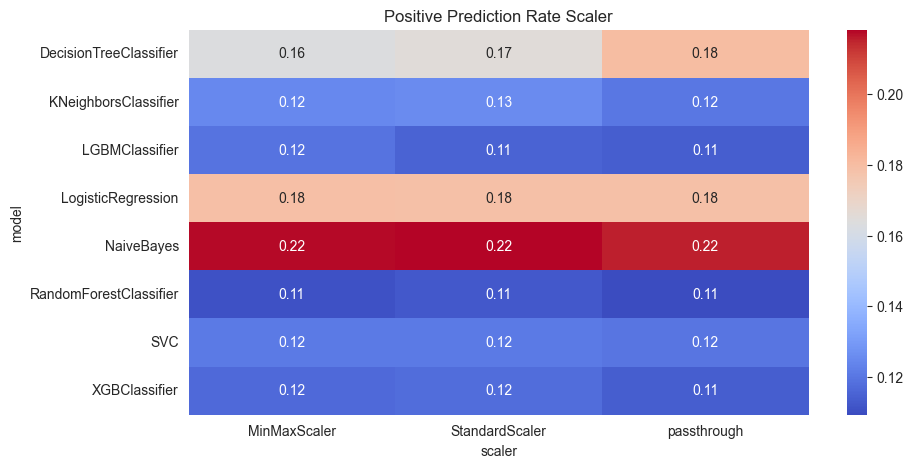

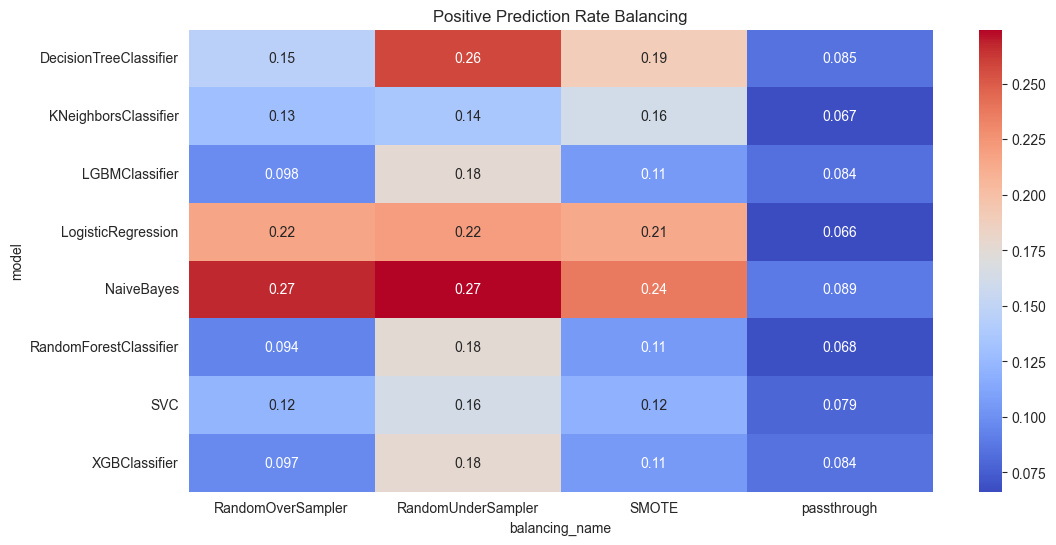

In [149]:

valid_data["predictions"] = valid_data["predictions"].apply(ast.literal_eval)

valid_data["positive_rate"] = valid_data["predictions"].apply(lambda x: sum(x) / len(x))

pivot_scaler = valid_data.pivot_table(
    values="positive_rate",
    index="model",
    columns="scaler",
    aggfunc="mean"
)
plt.figure(figsize=(10, 5))
sns.heatmap(pivot_scaler, annot=True, cmap="coolwarm")
plt.title("Positive Prediction Rate Scaler")
plt.show()

pivot_balancing_name = valid_data.pivot_table(
    values="positive_rate",
    index="model",
    columns="balancing_name",
    aggfunc="mean"
)
plt.figure(figsize=(12, 6))
sns.heatmap(pivot_balancing_name, annot=True, cmap="coolwarm")
plt.title("Positive Prediction Rate Balancing")
plt.show()



#### Figure description

The figure presents two heatmaps illustrating the **average positive prediction rate** generated by different classification models under various preprocessing configurations.
The upper heatmap shows how the **choice of feature scaler** influences the proportion of predictions classified as the positive class.
The lower heatmap illustrates how different **class balancing techniques** affect the frequency with which models predict the positive class.

The color gradient represents the proportion of observations predicted as the positive class, where warmer colors indicate a higher positive prediction rate.

---

#### Key observations

**Model vs scaler**

* The **choice of scaler has minimal influence** on the positive prediction rate for most models.
* **Naive Bayes** consistently produces the highest positive prediction rate (~0.22), indicating a stronger tendency to assign observations to the positive class.
* **Logistic Regression and Decision Trees** show moderately higher positive prediction rates compared to other models.
* **RandomForest, XGBoost, LightGBM, and SVC** predict the positive class less frequently (around **0.11–0.12**), suggesting more conservative decision boundaries.
* Overall, scaling does not significantly alter model prediction behavior in terms of class assignment.

---

**Model vs balancing method**

* The **balancing strategy strongly influences the positive prediction rate** across all models.
* **RandomUnderSampler significantly increases the proportion of positive predictions**, in some cases exceeding **0.25**, as the majority class is reduced.
* **RandomOverSampler and SMOTE moderately increase the positive prediction rate**, though the effect is smaller than with undersampling.
* When **no balancing method is applied**, models tend to predict the positive class much less frequently (often below **0.10**), indicating a bias toward the majority class.
* **Naive Bayes and Logistic Regression** consistently produce higher positive prediction rates across all balancing strategies.

---

#### Interpretation

The results indicate that **class balancing methods have a substantial impact on model prediction behavior**, particularly in terms of how frequently models assign observations to the positive class.
Reducing the size of the majority class (as in undersampling) increases the relative importance of minority samples during training, which leads models to predict the positive class more frequently.

In [150]:
valid_data["y_proba"] = valid_data["y_proba"].apply(ast.literal_eval)

rows = []

for _, row in valid_data.iterrows():
    for p in row["y_proba"]:
        rows.append({
            "model": row["model"],
            "balancing_name": row["balancing_name"],
            "probability": p
        })

proba_df = pd.DataFrame(rows)


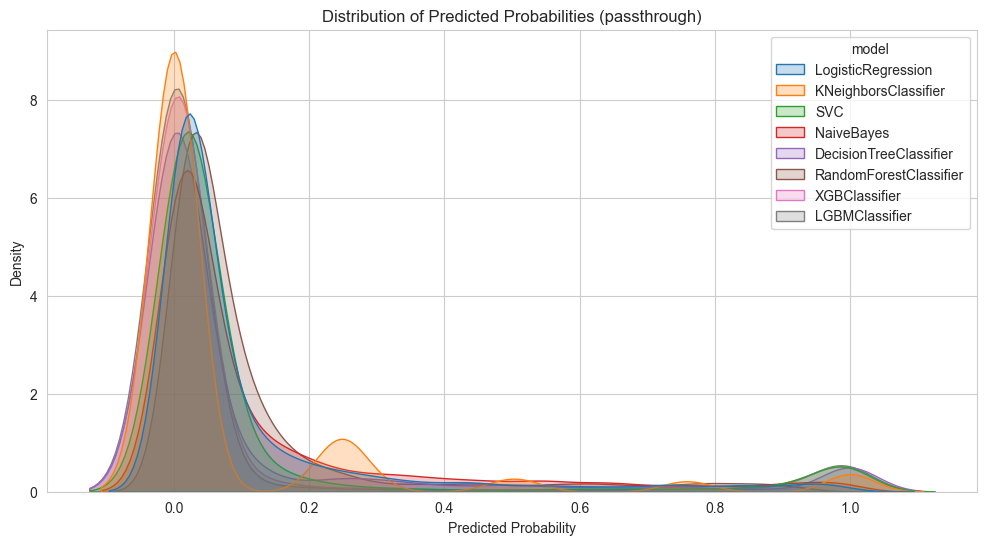

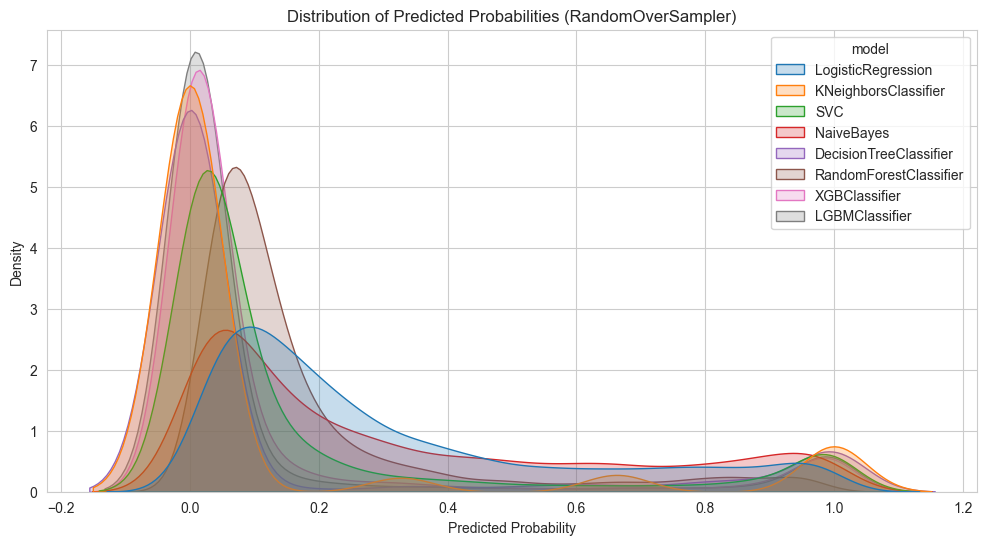

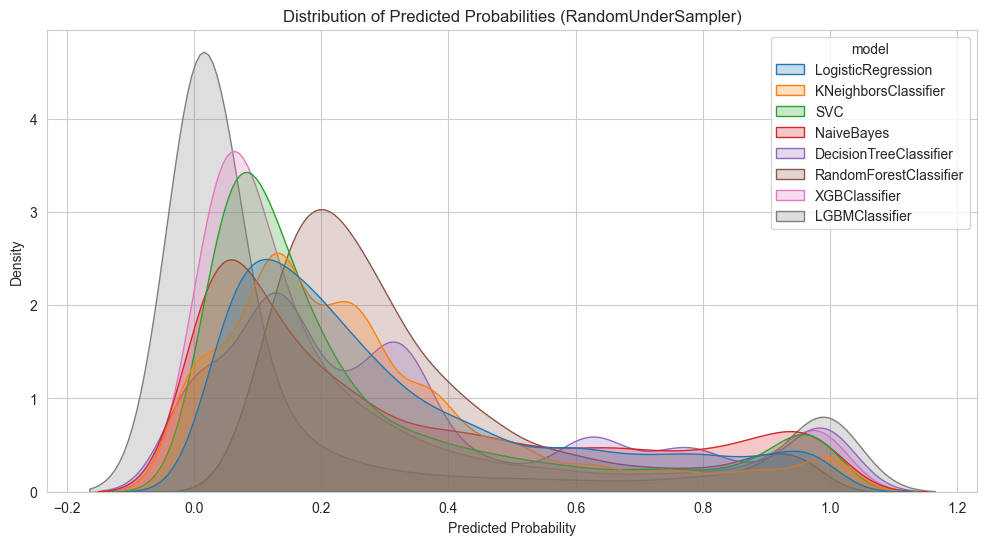

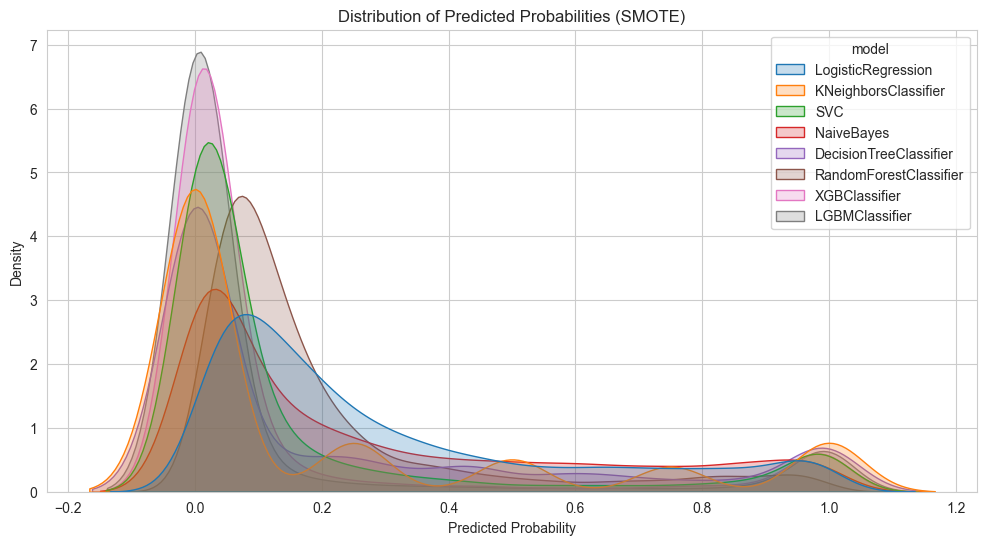

In [151]:


for balance in proba_df["balancing_name"].unique():
    subset = proba_df[proba_df["balancing_name"] == balance]

    plt.figure(figsize=(12, 6))

    sns.kdeplot(
        data=subset,
        x="probability",
        hue="model",
        fill=True,
        common_norm=False
    )

    plt.title(f"Distribution of Predicted Probabilities ({balance})")
    plt.xlabel("Predicted Probability")
    plt.ylabel("Density")

    plt.show()



#### Figure description

The figure presents **four probability density plots** showing the **distribution of predicted probabilities for the positive class** generated by multiple classification models under four different class imbalance handling strategies.

The plots correspond to models trained with the following configurations:

1. **passthrough** – no class balancing applied
2. **RandomOverSampler** – oversampling of the minority class
3. **RandomUnderSampler** – undersampling of the majority class
4. **SMOTE** – synthetic minority oversampling

The horizontal axis represents the predicted probability of the positive class, while the vertical axis shows the density of predictions.

---

#### Key observations

**Without balancing (passthrough)**

* Most predicted probabilities are heavily concentrated near **0**, indicating that the majority of observations are classified with a very low probability of belonging to the positive class.
* Only a small portion of predictions reach probabilities close to **1**, suggesting that models identify relatively few instances as strongly positive.
* The probability distributions across models are relatively similar, indicating consistent model behavior when trained on imbalanced data.
* Tree-based models (RandomForest, XGBoost, LightGBM) show sharper peaks near zero, reflecting stronger confidence in predicting the negative class.

---

**With RandomOverSampler**

* Oversampling noticeably **widens the distribution of predicted probabilities**, particularly in the mid-range probability region (approximately **0.1–0.4**).
* Models assign **higher probabilities to the positive class more frequently**, reflecting increased sensitivity to minority-class samples introduced during training.
* Logistic Regression and Naive Bayes exhibit broader distributions, suggesting a higher tendency to produce intermediate probability estimates.
* Ensemble models maintain relatively concentrated distributions but shift slightly toward higher probability values.

---

**With RandomUnderSampler**

* Undersampling significantly **alters the shape of the probability distributions**, resulting in more predictions in the mid-probability region.
* Since the majority class is reduced, models become **less biased toward the negative class** and more balanced in their probability estimates.
* Some models show wider probability spreads, indicating increased uncertainty in predictions due to the reduced training data.
* Tree-based models still maintain relatively structured distributions but shift toward higher probability regions.

---

**With SMOTE**

* SMOTE produces **probability distributions similar to RandomOverSampler**, but generally smoother due to the generation of synthetic minority samples.
* More observations appear in the **intermediate probability range**, indicating improved sensitivity to minority-class patterns.
* Models maintain stable peaks near zero while expanding toward higher probability regions.
* Ensemble models (RandomForest, XGBoost, LightGBM) remain relatively confident but demonstrate increased probability diversity.

---

#### Interpretation

The comparison across all four plots highlights how different **class balancing strategies influence the distribution of predicted probabilities**.

Without balancing, models exhibit a strong bias toward the majority class, resulting in predictions concentrated near zero probability.

Oversampling techniques (RandomOverSampler and SMOTE) increase the representation of minority-class samples during training, which shifts probability distributions toward higher values and improves model sensitivity.

RandomUnderSampler reduces the size of the majority class, which also increases the frequency of higher probability predictions but may introduce additional variance due to reduced training data.

---

#### Implication

These results demonstrate that **class balancing strategies significantly influence model confidence and probability calibration**.

Balancing techniques modify the learned decision boundaries and produce broader probability distributions, which can improve the detection of minority-class instances.

However, aggressive balancing methods may also introduce additional uncertainty or variance, highlighting the importance of carefully



## Final Benchmark Conclusions

The conducted benchmark evaluated multiple classification algorithms under different preprocessing configurations, including **feature scaling methods and class balancing strategies**. The analysis was based on several evaluation metrics: **accuracy, precision, recall, F1-score, ROC-AUC, and training time**.

The results provide several key insights into the behavior and performance of the examined models.

---

### 1. Ensemble models consistently deliver the strongest overall performance

Across nearly all evaluation metrics, **ensemble tree-based models** such as **LightGBM, XGBoost, and RandomForest** demonstrated the most robust and stable performance.

These models consistently achieved:

* the highest **accuracy scores (~0.93–0.95)**
* strong **F1-scores (~0.73–0.77)**
* high **ROC-AUC values (~0.90)**

This indicates that ensemble methods are highly effective at capturing complex patterns in the data and provide strong overall classification performance across different preprocessing configurations.

---

### 2. SVC achieves competitive performance but at higher computational cost

**Support Vector Classifier (SVC)** performed competitively across most evaluation metrics, often achieving the highest **ROC-AUC** and very strong **recall and F1-score** values.

However, SVC also showed **higher computational cost**, particularly when oversampling techniques were applied. This reflects the algorithm’s sensitivity to dataset size and computational complexity during training.

---

### 3. Feature scaling has limited impact on most models

The benchmark indicates that **feature scaling plays a relatively minor role in model performance**.

Tree-based models such as **RandomForest, LightGBM, and XGBoost** showed almost no sensitivity to scaling methods, which is consistent with theoretical expectations, as tree-based algorithms are inherently scale-invariant.

Only **distance-based algorithms**, particularly **KNN**, showed noticeable improvements when scaling was applied.

---

### 4. Class balancing strategies strongly influence model behavior

Handling class imbalance proved to be one of the most important preprocessing factors.

The results show that:

* **RandomOverSampler and SMOTE generally improve recall and F1-score**, particularly for ensemble models.
* **RandomUnderSampler increases recall but often decreases precision**, which can negatively affect the overall F1-score.
* In several cases, **no balancing produced the highest accuracy**, suggesting the dataset is dominated by the majority class.

This highlights the importance of selecting balancing techniques depending on the **specific evaluation metric and business objective**.

---

### 5. Trade-off between recall and precision when balancing classes

The experiments show a clear **precision–recall trade-off** when class balancing methods are applied.

Oversampling techniques increase the representation of the minority class, which improves **recall**, but may also increase **false positives**, lowering precision.

Conversely, when no balancing is applied, models tend to be more conservative in predicting the positive class, which leads to **higher precision but lower recall**.

---

### 6. Model choice should consider both performance and computational efficiency

While ensemble models achieve the strongest predictive performance, simpler algorithms such as **Naive Bayes and Logistic Regression** remain **computationally efficient and stable**, making them useful baselines or suitable options for resource-constrained environments.

Training time analysis shows that **dataset size and balancing strategies strongly affect computational cost**, particularly for complex models such as **SVC and RandomForest**.

---

## Overall conclusion

The benchmark demonstrates that **ensemble models combined with moderate oversampling techniques (such as SMOTE or RandomOverSampler)** provide the most balanced classification performance in this study.

At the same time, the results highlight that preprocessing choices—particularly **class balancing strategies**—can significantly influence model behavior and should be selected carefully depending on the problem context and performance priorities.

Overall, the study confirms that **model selection should balance predictive performance, robustness to class imbalance, and computational efficiency**.